# Multivariate Analysis

This notebook examines linear associations among suitable continuous numerical predictors and with the binary `failure` target. Correlation is descriptive EDA, not proof of causality or final feature usefulness.

In [1]:
from pathlib import Path
from itertools import combinations

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style='white', context='notebook')
ROOT = Path.cwd().parent
if not (ROOT / 'data' / 'raw' / 'wind_turbine_detection.csv').exists():
    ROOT = Path.cwd() / 'PROJECT 1'
df = pd.read_csv(ROOT / 'data' / 'raw' / 'wind_turbine_detection.csv')

excluded = {
    'timestamp': 'time identifier; analyse separately using time-aware methods',
    'turbine_id': 'categorical identifier, not a continuous measurement',
    'failure': 'binary target; excluded from the predictor-to-predictor matrix',
    'rated_power_kW': 'only five design-capacity levels; better handled as categorical or ordinal',
    'prior_fault_count': 'discrete event-count feature; not treated as continuous in this matrix',
}
numerical_features = [column for column in df.select_dtypes(include='number').columns if column not in excluded]

display(Markdown('## Numerical features selected for correlation analysis'))
display(pd.DataFrame({'selected_feature': numerical_features}))
display(Markdown('**Exclusions:** ' + '; '.join(f'`{column}` — {reason}' for column, reason in excluded.items()) + '.'))

## Numerical features selected for correlation analysis

,selected_feature
0,wind_speed_mps
1,wind_direction_deg
2,turbulence_intensity
3,air_density_kgm3
4,ambient_temp_C
5,humidity_pct
6,power_output_kW
7,rotor_speed_rpm
8,generator_speed_rpm
9,blade_pitch_angle_deg


**Exclusions:** `timestamp` — time identifier; analyse separately using time-aware methods; `turbine_id` — categorical identifier, not a continuous measurement; `failure` — binary target; excluded from the predictor-to-predictor matrix; `rated_power_kW` — only five design-capacity levels; better handled as categorical or ordinal; `prior_fault_count` — discrete event-count feature; not treated as continuous in this matrix.

## Predictor correlation matrix

,wind_speed_mps,wind_direction_deg,turbulence_intensity,air_density_kgm3,ambient_temp_C,humidity_pct,power_output_kW,rotor_speed_rpm,generator_speed_rpm,blade_pitch_angle_deg,...,vib_fft_bearing_bpfi,vib_fft_gearmesh,vib_fft_sideband,oil_particle_count,oil_pressure_bar,operating_hours_total,cumulative_energy_MWh,load_cycles,hours_since_last_maintenance,component_age_days
wind_speed_mps,1.000,0.021,0.240,0.033,-0.035,0.014,0.826,0.911,0.911,-0.357,...,-0.015,-0.006,-0.029,-0.016,-0.425,0.005,0.020,0.003,0.039,-0.002
wind_direction_deg,0.021,1.000,0.007,0.051,-0.053,0.001,0.033,0.019,0.019,-0.006,...,-0.031,-0.021,-0.041,-0.107,0.039,-0.032,-0.009,-0.212,-0.051,0.039
turbulence_intensity,0.240,0.007,1.000,0.014,-0.015,-0.002,0.199,0.219,0.219,-0.086,...,-0.002,-0.001,-0.009,-0.005,-0.102,-0.000,0.005,-0.000,0.010,0.001
air_density_kgm3,0.033,0.051,0.014,1.000,-0.964,-0.306,0.037,0.027,0.027,-0.009,...,-0.002,-0.024,-0.047,0.029,-0.054,0.004,0.004,0.017,0.012,-0.000
ambient_temp_C,-0.035,-0.053,-0.015,-0.964,1.000,0.317,-0.037,-0.028,-0.028,0.010,...,0.002,0.024,0.047,-0.029,0.055,-0.002,-0.002,-0.018,-0.014,0.000
humidity_pct,0.014,0.001,-0.002,-0.306,0.317,1.000,-0.011,0.017,0.017,-0.008,...,-0.099,0.023,0.027,-0.054,0.033,-0.004,-0.005,-0.179,0.185,-0.005
power_output_kW,0.826,0.033,0.199,0.037,-0.037,-0.011,1.000,0.757,0.757,-0.163,...,-0.011,-0.017,-0.033,-0.016,-0.431,-0.002,0.152,0.007,0.082,-0.003
rotor_speed_rpm,0.911,0.019,0.219,0.027,-0.028,0.017,0.757,1.000,1.000,-0.655,...,-0.018,-0.004,-0.022,-0.017,-0.387,-0.014,-0.002,0.001,0.035,0.003
generator_speed_rpm,0.911,0.019,0.219,0.027,-0.028,0.017,0.757,1.000,1.000,-0.654,...,-0.018,-0.004,-0.022,-0.017,-0.387,-0.014,-0.002,0.001,0.035,0.003
blade_pitch_angle_deg,-0.357,-0.006,-0.086,-0.009,0.010,-0.008,-0.163,-0.655,-0.654,1.000,...,0.015,-0.004,-0.001,0.006,0.085,0.037,0.033,0.001,-0.011,-0.013


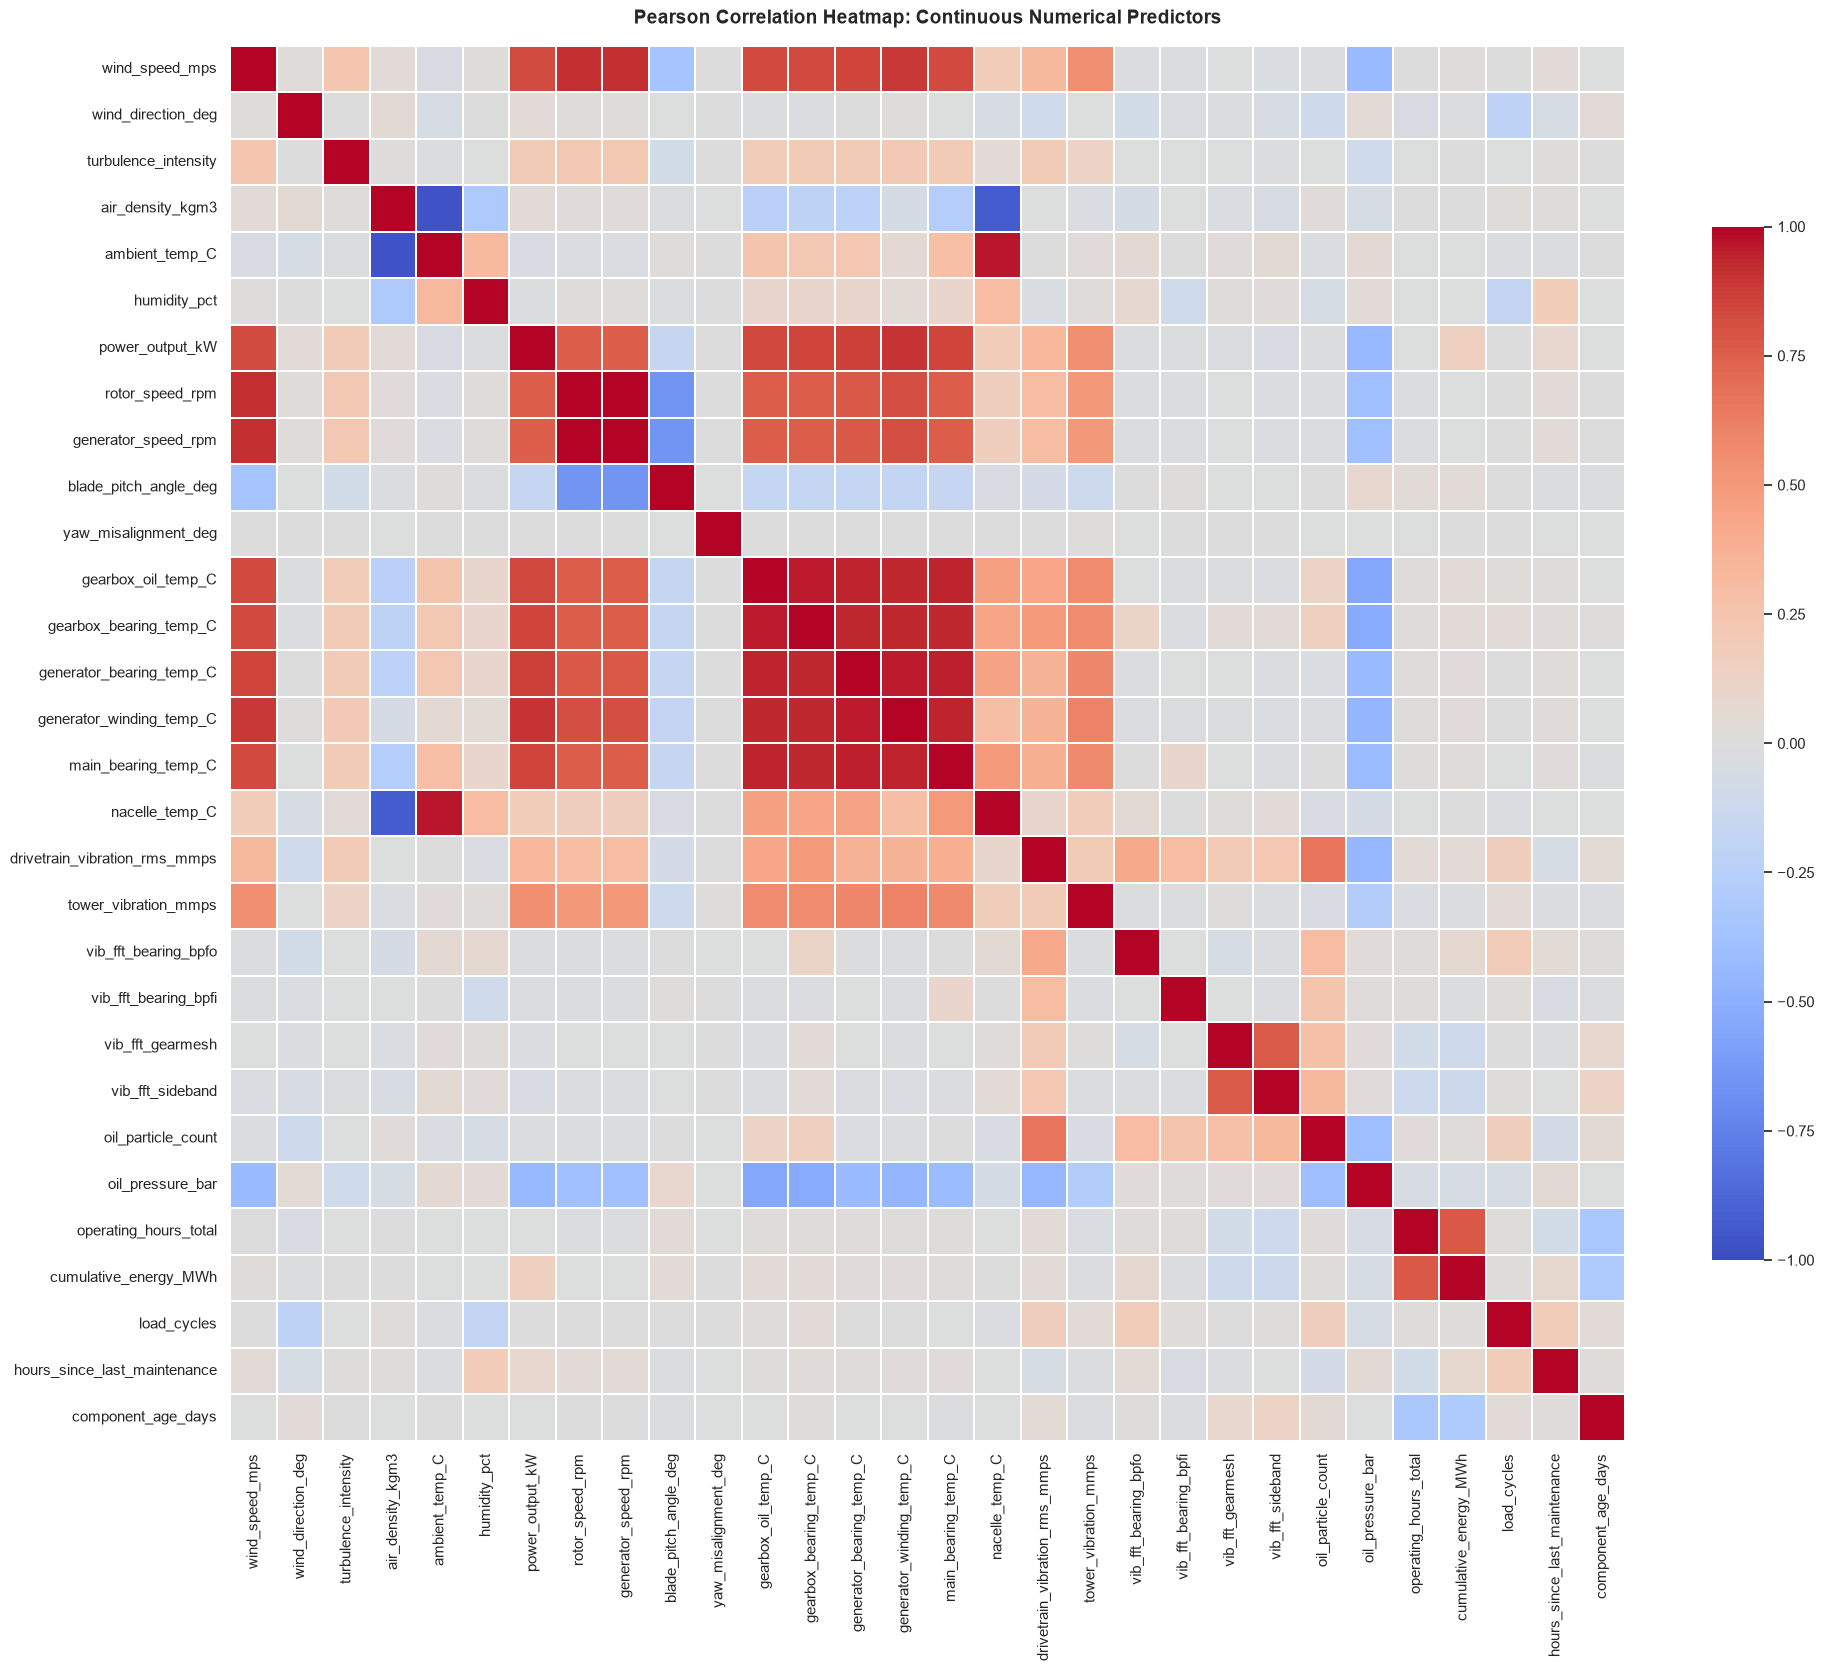

In [2]:
# Predictor correlation matrix and heatmap
correlation_matrix = df[numerical_features].corr(method='pearson')
display(Markdown('## Predictor correlation matrix'))
display(correlation_matrix.round(3))

fig, ax = plt.subplots(figsize=(20, 17))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1, square=True, linewidths=.25, cbar_kws={'shrink': .7}, ax=ax)
ax.set_title('Pearson Correlation Heatmap: Continuous Numerical Predictors', pad=16, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show(); plt.close(fig)

In [3]:
# Strong correlation pairs and groups of overlapping variables
strong_threshold = 0.80
pairs = []
for first, second in combinations(numerical_features, 2):
    coefficient = correlation_matrix.loc[first, second]
    if abs(coefficient) >= strong_threshold:
        pairs.append({'feature_1': first, 'feature_2': second, 'correlation': coefficient, 'absolute_correlation': abs(coefficient)})
strong_pairs = pd.DataFrame(pairs).sort_values('absolute_correlation', ascending=False).reset_index(drop=True) if pairs else pd.DataFrame(columns=['feature_1', 'feature_2', 'correlation', 'absolute_correlation'])
display(Markdown(f'## Strongly correlated pairs (|r| ≥ {strong_threshold:.2f})'))
display(strong_pairs.style.format({'correlation': '{:.3f}', 'absolute_correlation': '{:.3f}'}))

# Connected components of the strong-pair graph identify feature groups with overlapping information.
adjacency = {feature: set() for feature in numerical_features}
for row in strong_pairs.itertuples(index=False):
    adjacency[row.feature_1].add(row.feature_2)
    adjacency[row.feature_2].add(row.feature_1)
groups, visited = [], set()
for feature in numerical_features:
    if feature in visited or not adjacency[feature]:
        continue
    stack, component = [feature], set()
    while stack:
        current = stack.pop()
        if current not in component:
            component.add(current); visited.add(current); stack.extend(adjacency[current] - component)
    groups.append(sorted(component))

display(Markdown('## Potential multicollinearity groups'))
if groups:
    group_table = pd.DataFrame({'group': [f'Group {i + 1}' for i in range(len(groups))], 'features_with_strong_overlap': [', '.join(group) for group in groups], 'number_of_features': [len(group) for group in groups]})
    display(group_table)
    display(Markdown('**Interpretation:** These groups likely combine related turbine operating, thermal, vibration, or lifecycle measurements. Redundant predictors can make coefficient-based models unstable and can inflate the apparent importance of a shared signal. For subsequent classification, compare model performance with feature selection, regularisation, or carefully chosen representative variables. Tree models are less sensitive to multicollinearity for prediction, but importance can still be split across correlated features.'))
else:
    display(Markdown('No feature pairs exceeded the selected strong-correlation threshold.'))

## Strongly correlated pairs (|r| ≥ 0.80)

,feature_1,feature_2,correlation,absolute_correlation
0,rotor_speed_rpm,generator_speed_rpm,1.000,1.000
1,air_density_kgm3,ambient_temp_C,-0.964,0.964
2,ambient_temp_C,nacelle_temp_C,0.963,0.963
3,gearbox_oil_temp_C,gearbox_bearing_temp_C,0.960,0.960
4,generator_bearing_temp_C,generator_winding_temp_C,0.958,0.958
5,generator_bearing_temp_C,main_bearing_temp_C,0.952,0.952
6,generator_winding_temp_C,main_bearing_temp_C,0.943,0.943
7,gearbox_oil_temp_C,main_bearing_temp_C,0.941,0.941
8,gearbox_oil_temp_C,generator_bearing_temp_C,0.938,0.938
9,gearbox_bearing_temp_C,generator_winding_temp_C,0.937,0.937


## Potential multicollinearity groups

,group,features_with_strong_overlap,number_of_features
0,Group 1,"gearbox_bearing_temp_C, gearbox_oil_temp_C, ge...",9
1,Group 2,"air_density_kgm3, ambient_temp_C, nacelle_temp_C",3


**Interpretation:** These groups likely combine related turbine operating, thermal, vibration, or lifecycle measurements. Redundant predictors can make coefficient-based models unstable and can inflate the apparent importance of a shared signal. For subsequent classification, compare model performance with feature selection, regularisation, or carefully chosen representative variables. Tree models are less sensitive to multicollinearity for prediction, but importance can still be split across correlated features.

## Numerical-feature association with failure

,feature,correlation_with_failure,absolute_correlation
0,drivetrain_vibration_rms_mmps,0.5366,0.5366
1,oil_particle_count,0.4726,0.4726
2,vib_fft_bearing_bpfo,0.3163,0.3163
3,vib_fft_bearing_bpfi,0.2337,0.2337
4,vib_fft_sideband,0.1937,0.1937
5,vib_fft_gearmesh,0.1749,0.1749
6,oil_pressure_bar,-0.1694,0.1694
7,tower_vibration_mmps,0.1428,0.1428
8,load_cycles,0.1237,0.1237
9,gearbox_bearing_temp_C,0.0995,0.0995


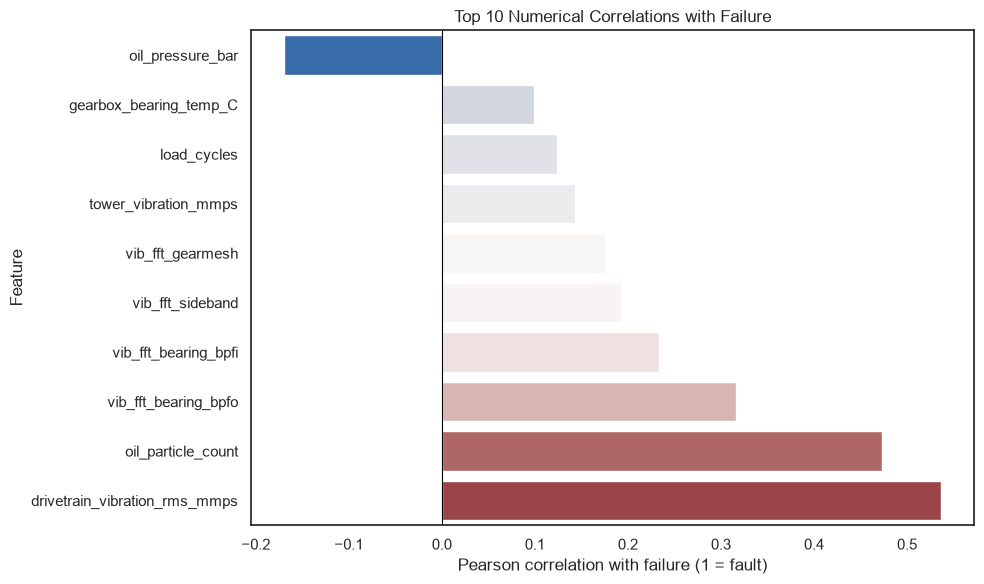

**Interpretation:** The strongest apparent linear associations with failure are `drivetrain_vibration_rms_mmps` (+0.537), `oil_particle_count` (+0.473), `vib_fft_bearing_bpfo` (+0.316), `vib_fft_bearing_bpfi` (+0.234), `vib_fft_sideband` (+0.194). Positive coefficients indicate higher values tend to occur with fault records; negative coefficients indicate lower values tend to occur with faults. These univariate linear associations do not establish causation, account for interactions, or guarantee predictive usefulness; validate candidates with leakage checks and time/turbine-aware modelling.

In [4]:
# Association with the binary failure target (point-biserial equivalent to Pearson for 0/1 target)
target_correlation = df[numerical_features + ['failure']].corr(method='pearson')['failure'].drop('failure')
target_ranking = pd.DataFrame({'feature': target_correlation.index, 'correlation_with_failure': target_correlation.values})
target_ranking['absolute_correlation'] = target_ranking['correlation_with_failure'].abs()
target_ranking = target_ranking.sort_values('absolute_correlation', ascending=False).reset_index(drop=True)
display(Markdown('## Numerical-feature association with failure'))
display(target_ranking.style.format({'correlation_with_failure': '{:.4f}', 'absolute_correlation': '{:.4f}'}))

top_features = target_ranking.head(10).sort_values('correlation_with_failure')
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_features, y='feature', x='correlation_with_failure', hue='correlation_with_failure', palette='vlag', legend=False, ax=ax)
ax.axvline(0, color='black', linewidth=.8)
ax.set(title='Top 10 Numerical Correlations with Failure', xlabel='Pearson correlation with failure (1 = fault)', ylabel='Feature')
plt.tight_layout(); plt.show(); plt.close(fig)
top_list = ', '.join(f'`{row.feature}` ({row.correlation_with_failure:+.3f})' for row in target_ranking.head(5).itertuples())
display(Markdown(f'**Interpretation:** The strongest apparent linear associations with failure are {top_list}. Positive coefficients indicate higher values tend to occur with fault records; negative coefficients indicate lower values tend to occur with faults. These univariate linear associations do not establish causation, account for interactions, or guarantee predictive usefulness; validate candidates with leakage checks and time/turbine-aware modelling.'))